# Exploratory Data Analysis (EDA)

This notebook focuses on extracting practical forecasting insights from energy consumption data.

## 1. Data Overview

In [ ]:
# Ensure project root is importable even when running from notebooks/
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "notebooks" else cwd
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import load_data

path = project_root / "data" / "raw" / "data.txt"
data = load_data(path)
data.head()

In [ ]:
data.shape

(2075259, 7)

In [ ]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


In [ ]:
# Missing values check & percentage (to 2 decimals)
missing_percentage = data.isnull().mean() * 100
print(missing_percentage.round(2))




Global_active_power      1.25
Global_reactive_power    1.25
Voltage                  1.25
Global_intensity         1.25
Sub_metering_1           1.25
Sub_metering_2           1.25
Sub_metering_3           1.25
dtype: float64


### 1.1 Missingness Structure Deep-Dive

We now test whether missing values are random or follow a structural pattern (shared timestamps, temporal concentration, and outage-like gaps).

In [ ]:
# Structural diagnostics: do missing values happen together across columns?
missing_mask = data.isna()
row_missing_count = missing_mask.sum(axis=1)
missing_any = row_missing_count > 0

rows_total = len(data)
rows_with_any_missing = int(missing_any.sum())
rows_all_columns_missing = int((row_missing_count == data.shape[1]).sum())

reference_col = missing_mask.iloc[:, 0]
column_pattern_match = missing_mask.apply(lambda col: col.equals(reference_col))
all_columns_share_same_pattern = bool(column_pattern_match.all())

print(f"Total rows: {rows_total:,}")
print(f"Rows with >=1 missing value: {rows_with_any_missing:,} ({rows_with_any_missing / rows_total * 100:.2f}%)")
print(f"Rows with all tracked columns missing: {rows_all_columns_missing:,}")
print(f"All columns share the same timestamp-level missing pattern: {all_columns_share_same_pattern}")

if rows_with_any_missing > 0:
    fully_shared_ratio = rows_all_columns_missing / rows_with_any_missing * 100
    print(f"Among rows with missing values, fully shared (all columns missing) rows: {fully_shared_ratio:.2f}%")

if not all_columns_share_same_pattern:
    print("Columns with different missing pattern:", list(column_pattern_match[~column_pattern_match].index))

print("\nFirst missing timestamps:")
print(data.index[missing_any][:10])

print("\nLast missing timestamps:")
print(data.index[missing_any][-10:])

Total rows: 2,075,259
Rows with >=1 missing value: 25,979 (1.25%)
Rows with all tracked columns missing: 25,979
All columns share the same timestamp-level missing pattern: True
Among rows with missing values, fully shared (all columns missing) rows: 100.00%

First missing timestamps:
DatetimeIndex(['2006-12-21 11:23:00', '2006-12-21 11:24:00',
               '2006-12-30 10:08:00', '2006-12-30 10:09:00',
               '2007-01-14 18:36:00', '2007-01-28 17:13:00',
               '2007-02-22 22:58:00', '2007-02-22 22:59:00',
               '2007-03-25 17:52:00', '2007-04-28 00:21:00'],
              dtype='datetime64[us]', name='datetime', freq=None)

Last missing timestamps:
DatetimeIndex(['2010-09-28 19:04:00', '2010-09-28 19:05:00',
               '2010-09-28 19:06:00', '2010-09-28 19:07:00',
               '2010-09-28 19:08:00', '2010-09-28 19:09:00',
               '2010-09-28 19:10:00', '2010-09-28 19:11:00',
               '2010-09-28 19:12:00', '2010-10-24 15:35:00'],
           

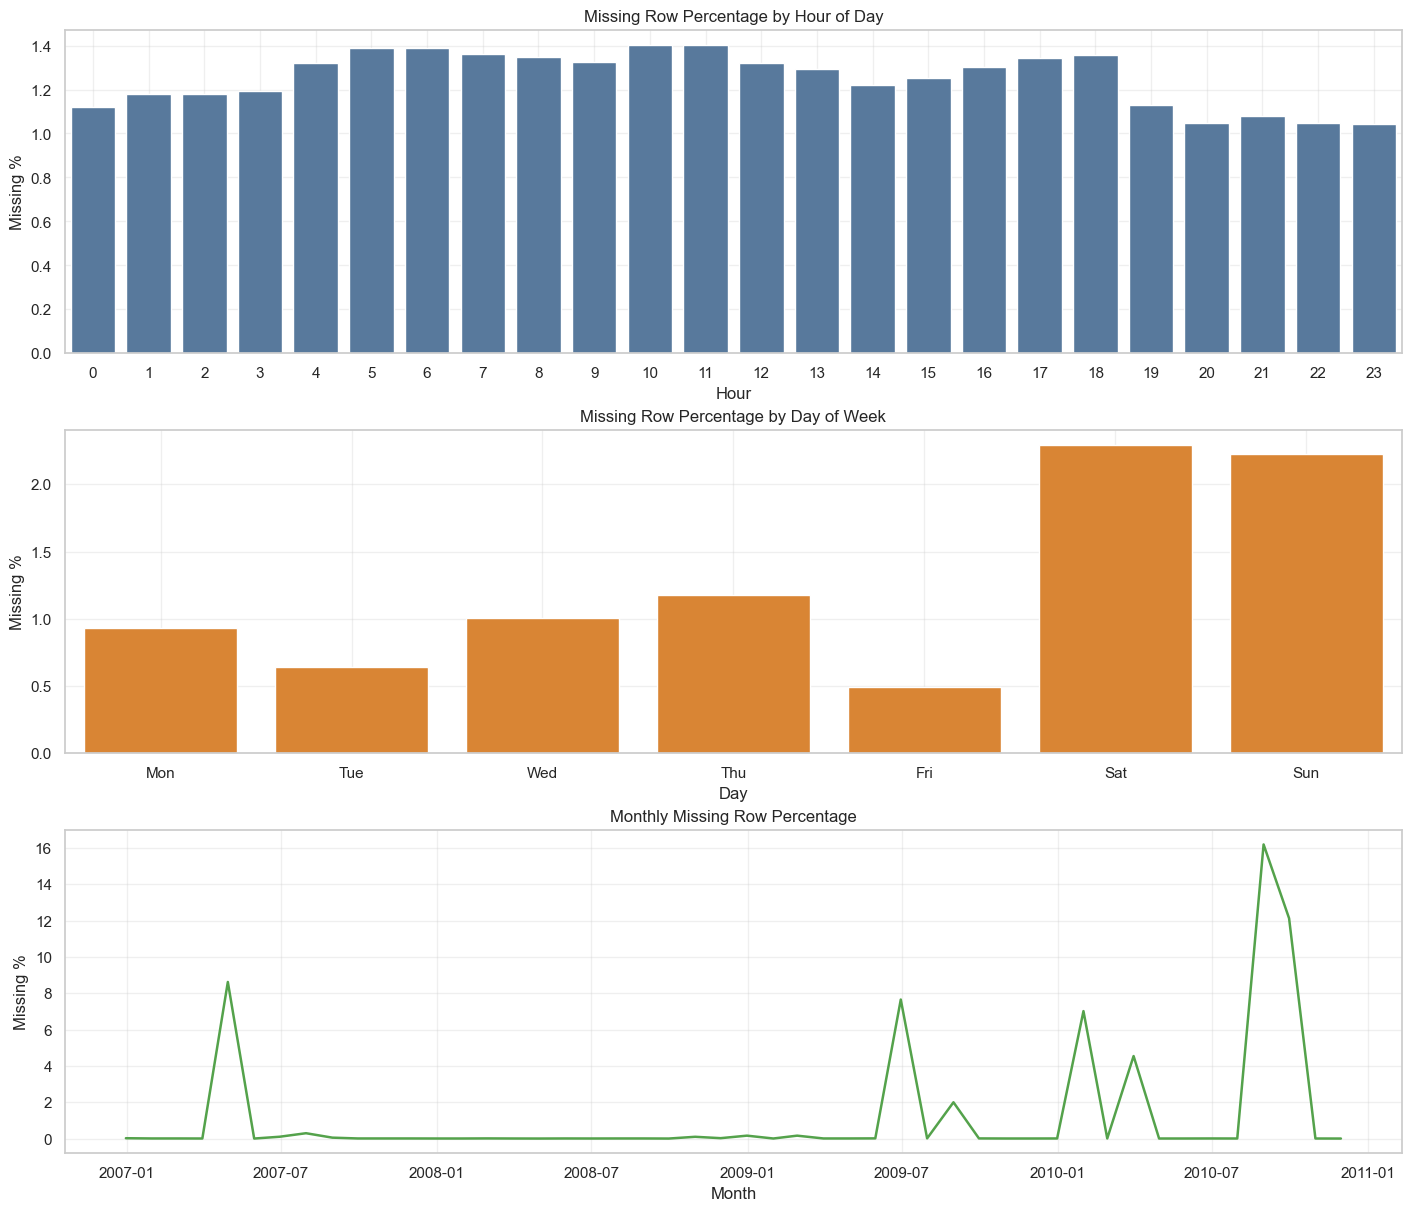

Hourly missing % (top 5 hours):
datetime
10    1.401804
11    1.401804
6     1.389082
5     1.387925
7     1.360167
Name: is_missing_row, dtype: float64

Day-of-week missing %:
datetime
0    0.934466
1    0.643878
2    1.004922
3    1.173813
4    0.489100
5    2.291303
6    2.228627
Name: is_missing_row, dtype: float64

Monthly missing % summary:
count    48.000
mean      1.232
std       3.399
min       0.000
25%       0.002
50%       0.005
75%       0.061
max      16.187
Name: is_missing_row, dtype: float64


In [ ]:
# Temporal diagnostics: when do missing rows occur?
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

missing_any = data.isna().any(axis=1)
missing_df = data.assign(is_missing_row=missing_any).copy()

hourly_missing_pct = missing_df.groupby(missing_df.index.hour)["is_missing_row"].mean() * 100
dow_missing_pct = missing_df.groupby(missing_df.index.dayofweek)["is_missing_row"].mean() * 100
monthly_missing_pct = missing_df["is_missing_row"].resample("ME").mean() * 100

fig, axes = plt.subplots(3, 1, figsize=(14, 12), constrained_layout=True)

sns.barplot(x=hourly_missing_pct.index, y=hourly_missing_pct.values, ax=axes[0], color="#4C78A8")
axes[0].set_title("Missing Row Percentage by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Missing %")

day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
sns.barplot(x=dow_missing_pct.index, y=dow_missing_pct.values, ax=axes[1], color="#F58518")
axes[1].set_title("Missing Row Percentage by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Missing %")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_labels)

axes[2].plot(monthly_missing_pct.index, monthly_missing_pct.values, color="#54A24B", linewidth=1.8)
axes[2].set_title("Monthly Missing Row Percentage")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Missing %")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.show()

print("Hourly missing % (top 5 hours):")
print(hourly_missing_pct.sort_values(ascending=False).head())

print("\nDay-of-week missing %:")
print(dow_missing_pct)

print("\nMonthly missing % summary:")
print(monthly_missing_pct.describe().round(3))

Number of missing gaps: 71
Average gap length (rows): 365.90
Median gap length (rows): 1.00
Max gap length (rows): 7226

Gap length quantiles (rows):
0.50       1.0
0.75       3.0
0.90      83.0
0.95    3217.0
0.99    5833.7
dtype: float64


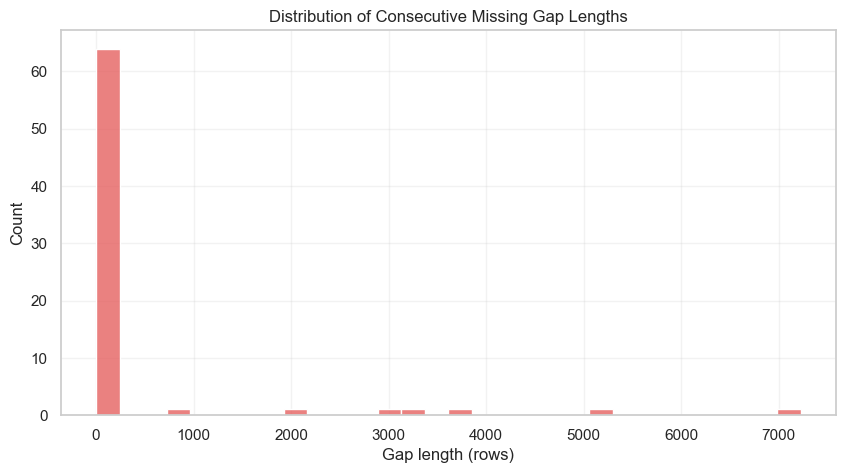

In [ ]:
# Gap-length diagnostics: are missings isolated points or outage-like blocks?
missing_any = data.isna().any(axis=1)

# Identify consecutive True segments in missing indicator.
groups = (missing_any != missing_any.shift(fill_value=False)).cumsum()
gap_lengths = missing_any.groupby(groups).sum()
gap_lengths = gap_lengths[gap_lengths > 0]

if len(gap_lengths) == 0:
    print("No missing gaps found.")
else:
    print(f"Number of missing gaps: {len(gap_lengths):,}")
    print(f"Average gap length (rows): {gap_lengths.mean():.2f}")
    print(f"Median gap length (rows): {gap_lengths.median():.2f}")
    print(f"Max gap length (rows): {int(gap_lengths.max())}")

    print("\nGap length quantiles (rows):")
    print(gap_lengths.quantile([0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

    plt.figure(figsize=(10, 5))
    sns.histplot(gap_lengths, bins=30, kde=False, color="#E45756")
    plt.title("Distribution of Consecutive Missing Gap Lengths")
    plt.xlabel("Gap length (rows)")
    plt.ylabel("Count")
    plt.grid(alpha=0.25)
    plt.show()

### 1.2 Interpretation of Missingness

- Missingness is **not feature-specific**: all tracked columns are missing at the exact same timestamps.
- This indicates a **data acquisition/recording outage pattern** rather than variable-level sensor noise.
- The process is **not missing completely at random (MCAR)**: missing rows cluster in specific months and are more frequent on weekends.
- Gap analysis shows a **mixture pattern**: many tiny gaps (median = 1 row) plus a few very long outage blocks (max = 7,226 rows).

### Practical modeling implication
- Prefer a two-stage strategy:
  1. Handle short isolated gaps with local interpolation or forward/backward fill.
  2. Treat long outage blocks as structural missing segments (drop, mask, or model-aware imputation).
- Add a missingness indicator feature if using ML models to preserve outage information as signal.

### 1.3 Production Missing-Data Policy (Applied)

This step applies the same policy used by the Python pipeline:
- Interpolate only short gaps
- Preserve long outage blocks as missing
- Add outage indicator features

In [ ]:
from src.preprocessing import apply_missing_value_policy, summarize_missing_gaps

# Preserve raw data for auditability, and update working dataset for downstream EDA.
data_raw = data.copy()
gap_summary = summarize_missing_gaps(data_raw)

data = apply_missing_value_policy(
    data_raw,
    short_gap_limit=3,
    interpolation_method="time",
)

print(f"Rows: {len(data):,}")
print(f"Columns after indicators: {data.shape[1]}")
print("Indicator columns added: is_missing_row, is_long_gap")

if not gap_summary.empty:
    print("\nGap summary (top 10 longest outages):")
    print(gap_summary.sort_values("length", ascending=False).head(10))

remaining_missing_pct = data.drop(columns=["is_missing_row", "is_long_gap"]).isna().mean().mul(100).round(3)
print("\nRemaining missing percentage after short-gap interpolation (%):")
print(remaining_missing_pct)

Rows: 2,075,259
Columns after indicators: 9
Indicator columns added: is_missing_row, is_long_gap

Gap summary (top 10 longest outages):
                 start                 end  length
68 2010-08-17 21:02:00 2010-08-22 21:27:00    7226
69 2010-09-25 03:56:00 2010-09-28 19:12:00    5237
6  2007-04-28 00:21:00 2007-04-30 14:23:00    3723
49 2009-06-13 00:30:00 2009-06-15 07:34:00    3305
58 2010-01-12 14:53:00 2010-01-14 19:01:00    3129
62 2010-03-20 03:52:00 2010-03-21 13:38:00    2027
51 2009-08-13 05:00:00 2009-08-13 19:50:00     891
15 2007-07-15 16:49:00 2007-07-15 18:11:00      83
38 2008-12-10 10:48:00 2008-12-10 11:57:00      70
16 2007-07-15 18:21:00 2007-07-15 19:07:00      47

Remaining missing percentage after short-gap interpolation (%):
Global_active_power      1.248
Global_reactive_power    1.248
Voltage                  1.248
Global_intensity         1.248
Sub_metering_1           1.248
Sub_metering_2           1.248
Sub_metering_3           1.248
dtype: float64


## 2. Time Series Visualization (Multi-Scale View)

### Objective
Understand behavior at global, medium, and short-term time scales.

### Required views
1. Full timeline (sampled) to inspect long-term trend
2. One-month window for medium-term variation
3. One-week window for daily cycle visibility

### What to extract
- Presence and stability of daily patterns
- Peak consistency over time
- Unusual periods or anomalies

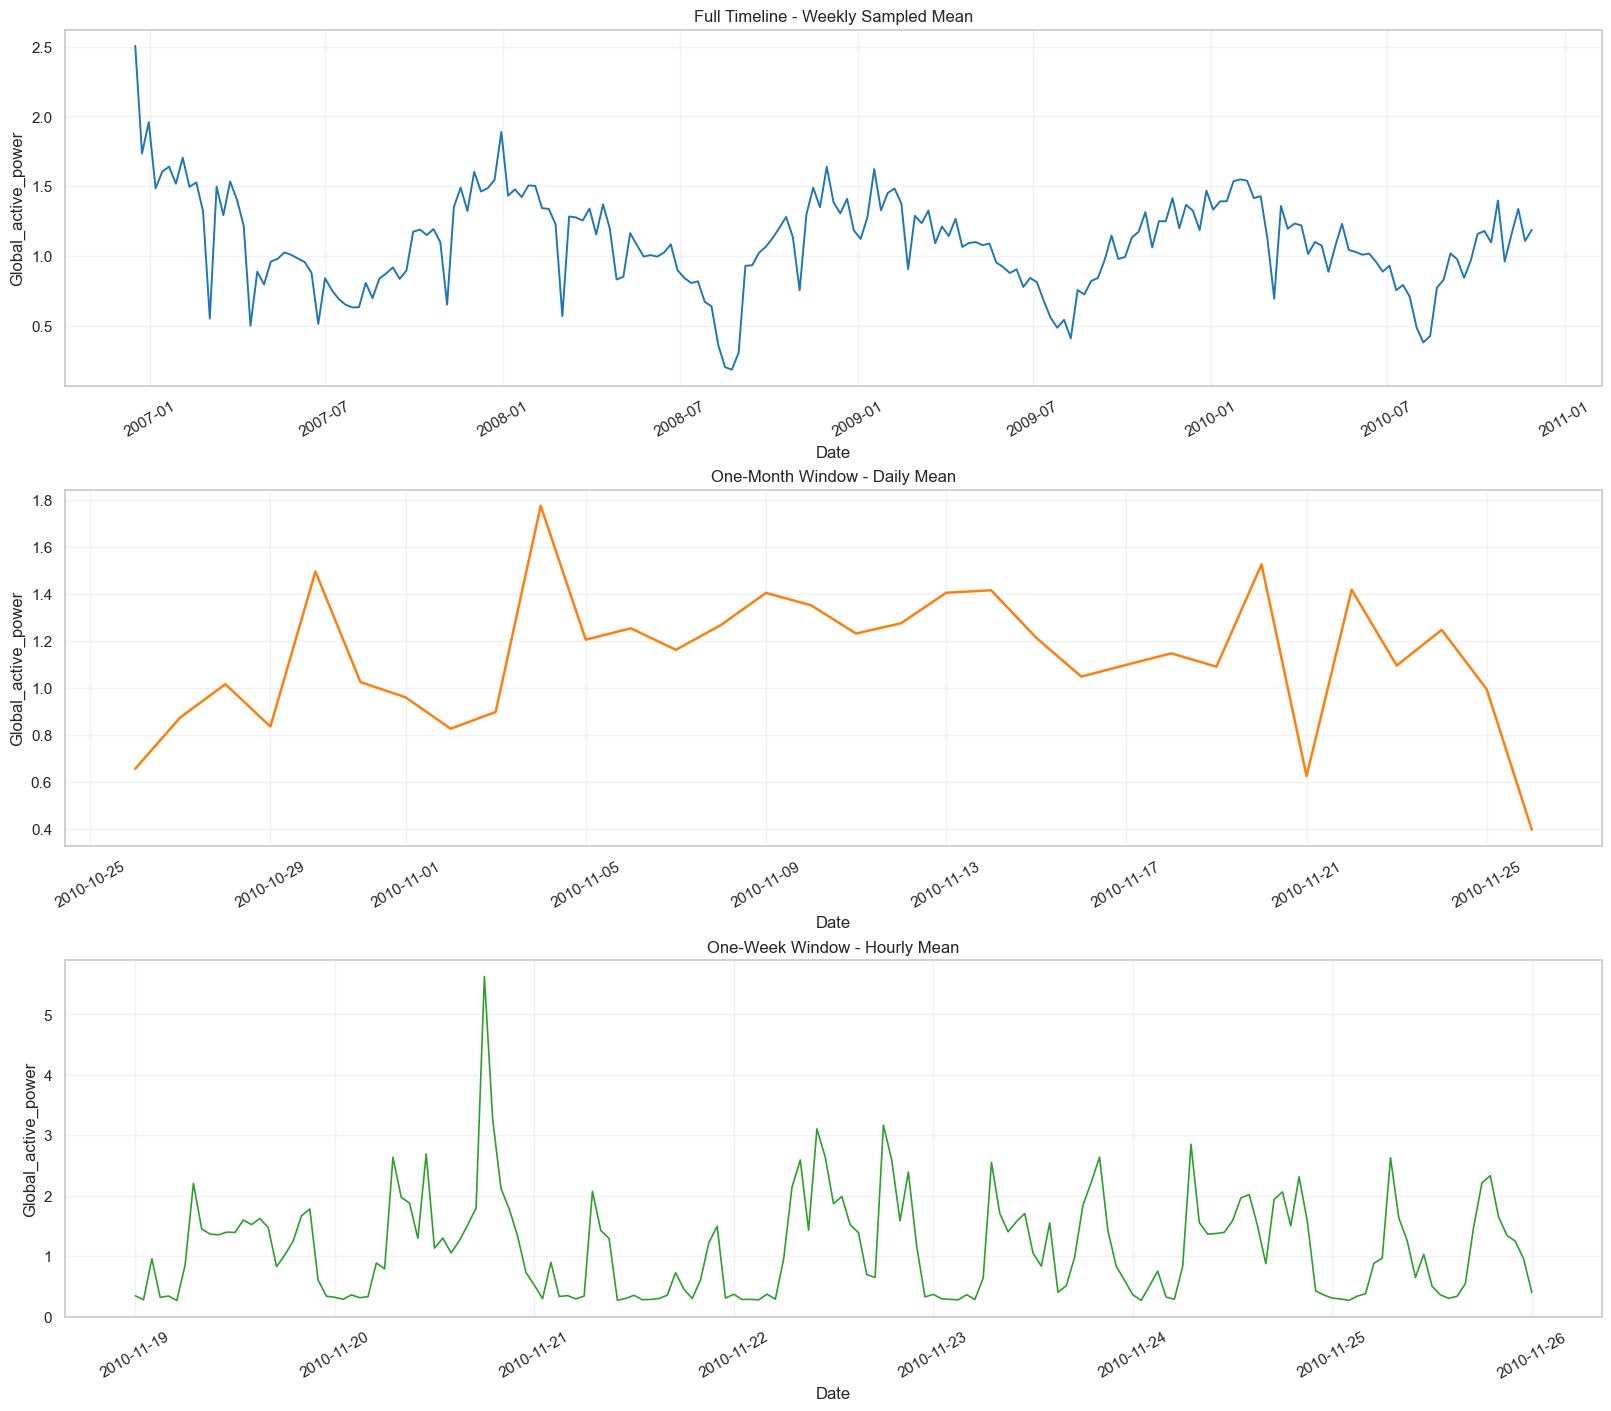

Time-series view created for: Global_active_power
Full timeline uses weekly sampling to show long-term trend.
One-month and one-week windows highlight medium-term variation and daily cycles.


In [ ]:
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

target = "Global_active_power"
ts = data.sort_index()
series = ts[target].dropna()

full_timeline = series.resample("W").mean()
month_end = series.index.max().normalize()
month_start = month_end - pd.DateOffset(months=1)
month_window = series.loc[month_start:month_end].resample("D").mean()
week_start = month_end - pd.DateOffset(days=7)
week_window = series.loc[week_start:month_end].resample("h").mean()

fig, axes = plt.subplots(3, 1, figsize=(16, 14), constrained_layout=True)

axes[0].plot(full_timeline.index, full_timeline.values, color="#1f77b4", linewidth=1.4)
axes[0].set_title("Full Timeline - Weekly Sampled Mean")
axes[0].set_xlabel("Date")
axes[0].set_ylabel(target)

axes[1].plot(month_window.index, month_window.values, color="#ff7f0e", linewidth=1.8)
axes[1].set_title("One-Month Window - Daily Mean")
axes[1].set_xlabel("Date")
axes[1].set_ylabel(target)

axes[2].plot(week_window.index, week_window.values, color="#2ca02c", linewidth=1.2)
axes[2].set_title("One-Week Window - Hourly Mean")
axes[2].set_xlabel("Date")
axes[2].set_ylabel(target)

for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="x", rotation=30)

plt.show()

print("Time-series view created for:", target)
print("Full timeline uses weekly sampling to show long-term trend.")
print("One-month and one-week windows highlight medium-term variation and daily cycles.")

## 3. Seasonality and Trend Decomposition

### Objective
Separate the signal into interpretable components.

### Components to analyze
- Trend
- Seasonal
- Residual

### Interpretation guide
- Strong seasonal component suggests SARIMA may perform well
- Large/noisy residuals may benefit from ML-based models
- A visible trend suggests differencing may be required

### 3.1 Stationarity Diagnostics (Why This Matters)

Before fitting ARIMA/SARIMA-style models, we test whether the target behaves like a stationary process.

- **ADF test** null hypothesis: the series has a unit root (non-stationary).
- **KPSS test** null hypothesis: the series is stationary (around level/trend depending on setting).

Using both reduces false confidence because they test opposite null hypotheses.

We test:
1. Original target series
2. First-differenced target series

Expected usage in modeling:
- If original is non-stationary and differenced is stationary, set differencing order `d=1` as a primary candidate.

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

target = "Global_active_power"
series = data[target].dropna()

# Downsample to hourly to reduce memory usage for stationarity tests
series_hourly = series.resample("h").mean().dropna()
series_diff1 = series_hourly.diff().dropna()

def run_stationarity_tests(ts, label):
    # adfuller with autolag=None returns 5 values (no IC best)
    adf_stat, adf_p, _, _, adf_crit = adfuller(ts, maxlag=40, autolag=None)
    kpss_stat, kpss_p, _, kpss_crit = kpss(ts, regression="c", nlags="auto")

    print(f"=== {label} ===")
    print(f"ADF p-value   : {adf_p:.6f}")
    print(f"KPSS p-value  : {kpss_p:.6f}")
    print(f"ADF statistic : {adf_stat:.4f}")
    print(f"KPSS statistic: {kpss_stat:.4f}")

    # Decision guidance at alpha=0.05.
    adf_stationary = adf_p < 0.05
    kpss_stationary = kpss_p > 0.05

    if adf_stationary and kpss_stationary:
        verdict = "Likely stationary"
    elif (not adf_stationary) and (not kpss_stationary):
        verdict = "Likely non-stationary"
    else:
        verdict = "Mixed evidence (inspect visually / consider seasonal effects)"

    print(f"Verdict       : {verdict}")
    print("ADF critical values:", {k: round(v, 4) for k, v in adf_crit.items()})
    print("KPSS critical values:", {k: round(v, 4) for k, v in kpss_crit.items()})
    print()

print("Testing on hourly-downsampled data (memory-efficient)\n")
run_stationarity_tests(series_hourly, "Original Series (Hourly)")
run_stationarity_tests(series_diff1, "First Difference (Hourly)")

Testing on hourly-downsampled data (memory-efficient)



C:\Users\Cesar Dushimimana\AppData\Local\Temp\ipykernel_36600\2711302059.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(ts, regression="c", nlags="auto")


=== Original Series (Hourly) ===
ADF p-value   : 0.000000
KPSS p-value  : 0.010000
ADF statistic : -18.5621
KPSS statistic: 1.1248
Verdict       : Mixed evidence (inspect visually / consider seasonal effects)
ADF critical values: {'1%': np.float64(-3.4305), '5%': np.float64(-2.8616), '10%': np.float64(-2.5668)}
KPSS critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}

=== First Difference (Hourly) ===
ADF p-value   : 0.000000
KPSS p-value  : 0.100000
ADF statistic : -42.5621
KPSS statistic: 0.0204
Verdict       : Likely stationary
ADF critical values: {'1%': np.float64(-3.4305), '5%': np.float64(-2.8616), '10%': np.float64(-2.5668)}
KPSS critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}



C:\Users\Cesar Dushimimana\AppData\Local\Temp\ipykernel_36600\2711302059.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(ts, regression="c", nlags="auto")


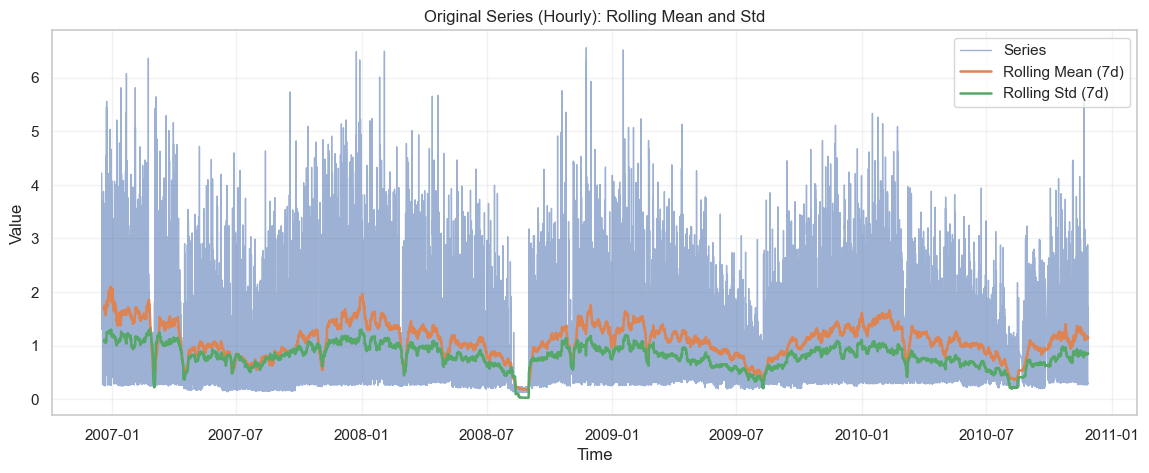

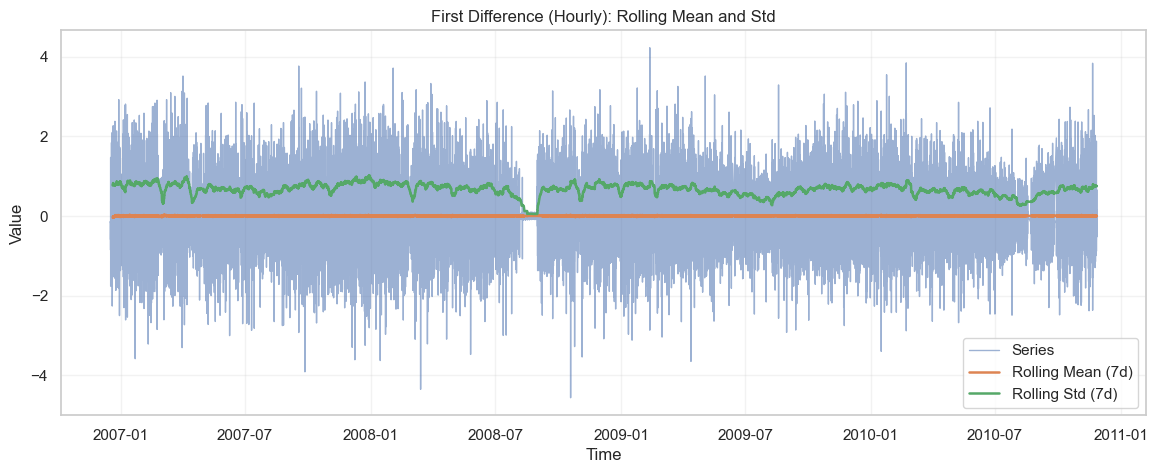

In [ ]:
# Visual cross-check: rolling behavior should stabilize after differencing if stationarity improves.
rolling_window = 24 * 7  # One week for hourly-like seasonality context.


def rolling_stats_plot(ts, title):
    roll_mean = ts.rolling(window=rolling_window, min_periods=rolling_window // 2).mean()
    roll_std = ts.rolling(window=rolling_window, min_periods=rolling_window // 2).std()

    plt.figure(figsize=(14, 5))
    plt.plot(ts.index, ts.values, label="Series", alpha=0.55, linewidth=1)
    plt.plot(roll_mean.index, roll_mean.values, label="Rolling Mean (7d)", linewidth=1.8)
    plt.plot(roll_std.index, roll_std.values, label="Rolling Std (7d)", linewidth=1.8)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

rolling_stats_plot(series_hourly, "Original Series (Hourly): Rolling Mean and Std")
rolling_stats_plot(series_diff1, "First Difference (Hourly): Rolling Mean and Std")

## 4. Autocorrelation Analysis (Feature Direction)

### Objective
Identify time dependencies that should guide lag-feature design.

### Plots to run
- ACF
- PACF

### Key interpretations
- Significant spike at lag 24 implies daily dependency
- Significant spike at lag 168 implies weekly dependency

### Modeling implication
Use significant lags as candidate predictive features rather than guessing.

## 5. Distribution Analysis

### Objective
Understand target distribution shape and modeling risk.

### Plots and checks
- Histogram
- Optional log-transform diagnostics

### What to determine
- Degree of skewness
- Presence of extreme values

### Modeling implication
- Strong skewness can reduce model stability
- Heavy tails can justify anomaly-focused analysis

## 6. Correlation Analysis

### Objective
Assess whether variables add unique signal or redundant information.

### Variables to compare
- Global_active_power
- Voltage
- Global_intensity
- Sub_metering variables

### Interpretation guide
- Strong correlation may indicate redundancy
- Weak/moderate correlation can indicate complementary signal

### Example decision
If Global_intensity is highly collinear with the target, it may add limited incremental value.

## 7. Sub-Metering Deep Dive

### Objective
Convert generic forecasting into interpretable energy-behavior analysis.

### Analyses to perform
- Average usage by sub-meter
- Time-of-day consumption profiles
- Seasonal variation by sub-meter

### Questions to answer
- Are kitchen-related loads peaking at expected hours?
- Is climate-related usage seasonally elevated?
- Are laundry/cyclic appliance patterns detectable?

## 8. Missing Data Pattern Analysis

### Objective
Validate that missing-value handling did not hide systematic issues.

### What to visualize
- Missingness over time

### Interpretation guide
- Random isolated gaps are usually acceptable
- Clustered gaps can indicate sensor/system outages

## 9. Key Insights

### 9.1 Daily Consumption Cycle
Energy consumption shows a strong daily cycle, with repeatable peak hours.

### 9.2 Weekly Seasonality
Weekly seasonality is visible, with distinct weekday/weekend behavior.

### 9.3 Predictive Lag Structure
Autocorrelation supports lag 24 and lag 168 as high-value predictive lags.

### 9.4 Sub-Metering Seasonal Effects
Sub_metering_3 exhibits seasonal spikes consistent with climate-related demand.

### 9.5 Distribution Risk Signal
The target distribution is right-skewed, indicating occasional high-consumption events.

## 2. Senior EDA Workflow (Production-Ready)

This section turns analysis into explicit decisions for downstream feature engineering and modeling.

Use the sequence below in order:
1. Define forecast setup and target clearly.
2. Freeze temporal validation windows.
3. Run leakage-risk checks before feature creation.
4. Review segment behavior (hour/day/month).
5. Produce a handoff table with decisions and actions.

### 2.1 Forecast Setup and Problem Contract

Fill this before continuing. If this is ambiguous, all later conclusions become unstable.

In [ ]:
# Configure this contract explicitly before modeling.
from dataclasses import dataclass
from typing import Optional

@dataclass
class ForecastContract:
    target_column: str = "Global_active_power"  # TODO: confirm exact target column in your data
    timestamp_column: Optional[str] = None       # None means DataFrame index is already DatetimeIndex
    horizon_steps: int = 24                      # e.g., forecast next 24 hourly points
    frequency: str = "H"                        # expected data frequency (H, 30T, D, ...)
    primary_metric: str = "MAE"
    guardrail_metrics: tuple = ("RMSE", "MAPE")

contract = ForecastContract()
print(contract)

ForecastContract(target_column='Global_active_power', timestamp_column=None, horizon_steps=24, frequency='H', primary_metric='MAE', guardrail_metrics=('RMSE', 'MAPE'))


In [ ]:
# Data quality gate: compact audit table for decision-making.
import pandas as pd

eda_audit = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing_pct": (data.isna().mean() * 100).round(3),
    "n_unique": data.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

display(eda_audit.head(20))
print(f"Rows: {len(data):,}, Columns: {data.shape[1]}")
print(f"Index type: {type(data.index).__name__}")
print(f"Start: {data.index.min()} | End: {data.index.max()}")

,dtype,missing_pct,n_unique
Global_active_power,float64,1.252,4186
Global_reactive_power,float64,1.252,532
Voltage,float64,1.252,2837
Global_intensity,float64,1.252,221
Sub_metering_1,float64,1.252,88
Sub_metering_2,float64,1.252,81
Sub_metering_3,float64,1.252,32


Rows: 2,075,259, Columns: 7
Index type: DatetimeIndex
Start: 2006-12-16 17:24:00 | End: 2010-11-26 21:02:00


### 2.2 Temporal Validation Design (No Leakage)

Define rolling-origin splits now and keep them fixed through modeling and tuning.

In [ ]:
# Rolling-origin split template (time-series safe).
def build_rolling_splits(df, n_folds=4, train_days=180, valid_days=30):
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("DataFrame index must be a DatetimeIndex for temporal splitting.")

    split_rows = []
    end = df.index.max()

    for fold in range(n_folds, 0, -1):
        valid_end = end - pd.Timedelta(days=(fold - 1) * valid_days)
        valid_start = valid_end - pd.Timedelta(days=valid_days) + pd.Timedelta(hours=1)
        train_end = valid_start - pd.Timedelta(hours=1)
        train_start = train_end - pd.Timedelta(days=train_days) + pd.Timedelta(hours=1)

        train_mask = (df.index >= train_start) & (df.index <= train_end)
        valid_mask = (df.index >= valid_start) & (df.index <= valid_end)

        split_rows.append({
            "fold": n_folds - fold + 1,
            "train_start": train_start,
            "train_end": train_end,
            "valid_start": valid_start,
            "valid_end": valid_end,
            "train_rows": int(train_mask.sum()),
            "valid_rows": int(valid_mask.sum())
        })

    return pd.DataFrame(split_rows)

split_plan = build_rolling_splits(data, n_folds=4, train_days=180, valid_days=30)
display(split_plan)

,fold,train_start,train_end,valid_start,valid_end,train_rows,valid_rows
0,1,2010-01-30 22:02:00,2010-07-29 21:02:00,2010-07-29 22:02:00,2010-08-28 21:02:00,259141,43141
1,2,2010-03-01 22:02:00,2010-08-28 21:02:00,2010-08-28 22:02:00,2010-09-27 21:02:00,259141,43141
2,3,2010-03-31 22:02:00,2010-09-27 21:02:00,2010-09-27 22:02:00,2010-10-27 21:02:00,259141,43141
3,4,2010-04-30 22:02:00,2010-10-27 21:02:00,2010-10-27 22:02:00,2010-11-26 21:02:00,259141,43141


### 2.3 Leakage Risk Register

List candidate features and mark whether they are safe at forecast creation time.

Rule: a feature is valid only if it can be computed using information available at prediction timestamp.

In [ ]:
# Initialize and maintain this table through feature engineering.
leakage_register = pd.DataFrame([
    {"feature": "hour", "category": "calendar", "available_at_prediction_time": True, "risk_note": "Safe"},
    {"feature": "day_of_week", "category": "calendar", "available_at_prediction_time": True, "risk_note": "Safe"},
    {"feature": "lag_1", "category": "lag", "available_at_prediction_time": True, "risk_note": "Safe if built with strict shift"},
    {"feature": "rolling_mean_24", "category": "rolling", "available_at_prediction_time": True, "risk_note": "Safe if based only on past values"},
    {"feature": "future_temperature", "category": "external", "available_at_prediction_time": False, "risk_note": "Leakage unless forecasted weather is used"},
])

display(leakage_register)

,feature,category,available_at_prediction_time,risk_note
0,hour,calendar,True,Safe
1,day_of_week,calendar,True,Safe
2,lag_1,lag,True,Safe if built with strict shift
3,rolling_mean_24,rolling,True,Safe if based only on past values
4,future_temperature,external,False,Leakage unless forecasted weather is used


### 2.4 Segment Diagnostics (Behavioral Stability)

Measure target behavior by hour/day/month so model evaluation can later be checked by segment, not only globally.

In [ ]:
# Segment profile for the selected target.
target_col = contract.target_column
if target_col not in data.columns:
    raise KeyError(f"Target column '{target_col}' not found. Update contract.target_column first.")

segment_df = pd.DataFrame({
    "target": data[target_col],
    "hour": data.index.hour,
    "day_of_week": data.index.dayofweek,
    "month": data.index.month
})

hour_profile = segment_df.groupby("hour")["target"].agg(["mean", "std", "min", "max"]).round(3)
dow_profile = segment_df.groupby("day_of_week")["target"].agg(["mean", "std", "min", "max"]).round(3)
month_profile = segment_df.groupby("month")["target"].agg(["mean", "std", "min", "max"]).round(3)

print("Hourly profile")
display(hour_profile)
print("Day-of-week profile")
display(dow_profile)
print("Monthly profile")
display(month_profile)

Hourly profile


,mean,std,min,max
hour,,,,
0,0.659,0.718,0.078,7.698
1,0.539,0.586,0.078,10.290
2,0.481,0.489,0.078,6.248
3,0.445,0.430,0.078,4.426
4,0.444,0.425,0.078,4.796
5,0.454,0.446,0.078,6.376
6,0.792,0.929,0.078,8.310
7,1.502,1.082,0.078,9.486
8,1.461,0.950,0.078,8.126


Day-of-week profile


,mean,std,min,max
day_of_week,,,,
0,1.000,0.956,0.078,9.486
1,1.070,1.019,0.076,9.732
2,1.083,1.027,0.078,8.974
3,0.982,0.959,0.076,9.410
4,1.043,0.971,0.078,9.590
5,1.248,1.191,0.078,9.724
6,1.220,1.219,0.078,11.122


Monthly profile


,mean,std,min,max
month,,,,
1,1.462,1.223,0.198,10.162
2,1.300,1.164,0.198,11.122
3,1.231,1.103,0.196,10.670
4,1.047,0.977,0.104,9.482
5,1.030,0.939,0.106,8.944
6,0.909,0.895,0.082,8.760
7,0.700,0.732,0.098,7.240
8,0.573,0.722,0.076,8.694
9,0.976,0.953,0.098,8.110


### 2.5 EDA-to-Feature-Engineering Handoff

Before leaving EDA, write explicit decisions. This prevents accidental scope drift in feature engineering.

In [ ]:
# Final decision artifact from EDA.
feature_handoff = pd.DataFrame([
    {"item": "Target", "decision": contract.target_column, "action_for_next_notebook": "Use as y"},
    {"item": "Horizon", "decision": contract.horizon_steps, "action_for_next_notebook": "Create supervised windows accordingly"},
    {"item": "Validation", "decision": "Rolling-origin (fixed splits)", "action_for_next_notebook": "Reuse split_plan exactly"},
    {"item": "Missingness", "decision": "Two-stage handling (short gaps vs long outages)", "action_for_next_notebook": "Implement gap-length-based imputation/masking"},
    {"item": "Leakage policy", "decision": "Only features available at prediction time", "action_for_next_notebook": "Keep and update leakage_register"},
    {"item": "Segment checks", "decision": "Track hour/day/month behavior", "action_for_next_notebook": "Report metrics by segment in modeling"},
])

display(feature_handoff)

# Optional: persist handoff to reports for traceability.
# feature_handoff.to_csv(project_root / "reports" / "eda_feature_handoff.csv", index=False)

,item,decision,action_for_next_notebook
0,Target,Global_active_power,Use as y
1,Horizon,24,Create supervised windows accordingly
2,Validation,Rolling-origin (fixed splits),Reuse split_plan exactly
3,Missingness,Two-stage handling (short gaps vs long outages),Implement gap-length-based imputation/masking
4,Leakage policy,Only features available at prediction time,Keep and update leakage_register
5,Segment checks,Track hour/day/month behavior,Report metrics by segment in modeling
